In [1]:
import sys; sys.path.append("..")

import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.sparse import triu
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict

from src.config import ARTIFACTS, DATA_PROC, REL_THRESHOLD, REPORTS, TOP_K
from src.evaluate import bootstrap_ci, evaluate_ranking, evaluate_rating
from src.metrics import mae, rmse
from src.models.baselines import BiasModel, Popularity, RandomRec
from src.models.content import ContentBased, build_item_features
from src.models.hybrid import HybridEngine, fold_in_content, fold_in_knn, fold_in_mf
from src.models.knn import ItemKNN, UserKNN
from src.models.mf import BiasedMF

train = pd.read_parquet(DATA_PROC / "train.parquet")
val = pd.read_parquet(DATA_PROC / "val.parquet")
test = pd.read_parquet(DATA_PROC / "test.parquet")
movies = pd.read_parquet(DATA_PROC / "movies.parquet")
trainval = pd.concat([train, val], ignore_index=True)
n_users = 610
n_items = len(movies)
assert np.array_equal(movies["i"].to_numpy(), np.arange(n_items))

content_config = json.loads((ARTIFACTS / "content_config.json").read_text())
knn_config = json.loads((ARTIFACTS / "knn_config.json").read_text())
mf_config = json.loads((ARTIFACTS / "mf_config.json").read_text())
hybrid_config = json.loads((ARTIFACTS / "hybrid_config.json").read_text())

# Final models are refit on train + validation; configs and weights stay frozen.
bias_final = BiasModel().fit(trainval, n_users, n_items)
pop_count_final = Popularity("count").fit(trainval, n_users, n_items)
pop_bayes_final = Popularity("bayes").fit(trainval, n_users, n_items)
random_final = RandomRec(seed=42).fit(trainval, n_users, n_items)

content_features, feature_vectorizers = build_item_features(
    movies,
    w_genre=content_config["w_genre"],
    w_tag=content_config["w_tag"],
    w_decade=content_config["w_decade"],
    use_genre=content_config["use_genre"],
    use_tag=content_config["use_tag"],
    use_decade=content_config["use_decade"],
)
content_final = ContentBased(
    content_features,
    profile_mode=content_config["profile_mode"],
    popularity_weight=content_config["popularity_weight"],
).fit(trainval, n_users, n_items)

item_rating_config = knn_config["item_knn"]["rmse_best"]
item_rank_config = knn_config["item_knn"]["ndcg_best"]
user_rating_config = knn_config["user_knn"]["rmse_best"]
user_rank_config = knn_config["user_knn"]["ndcg_best"]

def fit_item_knn(config, mode="residual"):
    return ItemKNN(
        bias_final,
        k=config["k"],
        shrink=config["shrink"],
        damp=config["damp"],
        mode=mode,
    ).fit(trainval, n_users, n_items)


def fit_user_knn(config, mode="residual"):
    return UserKNN(
        bias_final,
        k=config["k"],
        shrink=config["shrink"],
        damp=config["damp"],
        mode=mode,
    ).fit(trainval, n_users, n_items)


item_knn_rating = fit_item_knn(item_rating_config)
item_knn_final = fit_item_knn(item_rank_config)
item_knn_implicit = fit_item_knn(item_rank_config, mode="implicit")
user_knn_rating = fit_user_knn(user_rating_config)
user_knn_final = fit_user_knn(user_rank_config)
user_knn_implicit = fit_user_knn(user_rank_config, mode="implicit")


def fit_mf(config, frame):
    parameters = {
        key: config[key]
        for key in ("n_factors", "lr", "reg", "init_std", "seed", "patience")
    }
    parameters["epochs"] = int(config["best_epoch"])
    parameters["verbose"] = False
    return BiasedMF(**parameters).fit(frame, n_users, n_items)


mf_rmse_final = fit_mf(mf_config["mf_rmse"], trainval)
mf_ndcg_final = fit_mf(mf_config["mf_ndcg"], trainval)
hybrid_final = HybridEngine(
    mf_ndcg_final,
    item_knn_final,
    content_final,
    pop_count_final,
    bias_final,
    hybrid_config["weights"],
    n_items,
    weights_cold=hybrid_config["weights_cold"],
    cold_threshold=hybrid_config["cold_threshold"],
)

# Refit the stack on validation features from train-only models, then use frozen artifact coefficients.
bias_train = BiasModel().fit(train, n_users, n_items)
item_knn_train = ItemKNN(
    bias_train, k=item_rating_config["k"], shrink=item_rating_config["shrink"],
    damp=item_rating_config["damp"], mode="residual",
).fit(train, n_users, n_items)
user_knn_train = UserKNN(
    bias_train, k=user_rating_config["k"], shrink=user_rating_config["shrink"],
    damp=user_rating_config["damp"], mode="residual",
).fit(train, n_users, n_items)
mf_train = fit_mf(mf_config["mf_rmse"], train)
stacking = hybrid_config["stacking"]
stack_features_val = np.column_stack([
    bias_train.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    item_knn_train.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    user_knn_train.predict(val["u"].to_numpy(), val["i"].to_numpy()),
    mf_train.predict(val["u"].to_numpy(), val["i"].to_numpy()),
])
stack_refit = Ridge(alpha=stacking["alpha"], positive=True).fit(
    stack_features_val, val["rating"].to_numpy(dtype=float)
)
print("Frozen stack feature order:", stacking["features"])
print("Validation refit stack coefficients (frozen artifact coefficients are used on test):", stack_refit.coef_)

class FixedPredictions:
    def __init__(self, predictions):
        self.predictions = np.asarray(predictions, dtype=float)

    def predict(self, u, i):
        return self.predictions


test_users = test["u"].to_numpy()
test_items = test["i"].to_numpy()
test_targets = test["rating"].to_numpy(dtype=float)
rating_models = {
    "bias": bias_final,
    "item_knn": item_knn_rating,
    "user_knn": user_knn_rating,
    "mf": mf_rmse_final,
}
rating_params = {
    "bias": {"source": "trainval"},
    "item_knn": {**item_rating_config, "mode": "residual", "selected_for": "rmse"},
    "user_knn": {**user_rating_config, "mode": "residual", "selected_for": "rmse"},
    "mf": {**mf_config["mf_rmse"], "epochs": mf_config["mf_rmse"]["best_epoch"]},
}
rating_predictions = {}
rating_metrics = {}
for name, model in rating_models.items():
    clipped = np.clip(model.predict(test_users, test_items), 0.5, 5.0)
    rating_predictions[name] = clipped
    rating_metrics[name] = evaluate_rating(FixedPredictions(clipped), test)

stack_features_test = np.column_stack([
    bias_final.predict(test_users, test_items),
    item_knn_rating.predict(test_users, test_items),
    user_knn_rating.predict(test_users, test_items),
    mf_rmse_final.predict(test_users, test_items),
])
frozen_stack_predictions = np.clip(
    float(stacking["intercept"])
    + stack_features_test @ np.asarray(stacking["coefficients"], dtype=float),
    0.5,
    5.0,
)
rating_predictions["hybrid_stack"] = frozen_stack_predictions
rating_metrics["hybrid_stack"] = evaluate_rating(
    FixedPredictions(frozen_stack_predictions), test
)

ranking_models = {
    "random": random_final,
    "popularity_count": pop_count_final,
    "popularity_bayes": pop_bayes_final,
    "bias": bias_final,
    "content": content_final,
    "item_knn": item_knn_final,
    "user_knn": user_knn_final,
    "item_knn_implicit": item_knn_implicit,
    "user_knn_implicit": user_knn_implicit,
    "mf": mf_rmse_final,
    "mf_ndcg": mf_ndcg_final,
    "hybrid": hybrid_final,
}
ranking_params = {
    "random": {"seed": 42},
    "popularity_count": {"mode": "count"},
    "popularity_bayes": {"mode": "bayes", "m": 15},
    "bias": {"source": "trainval"},
    "content": content_config,
    "item_knn": {**item_rank_config, "mode": "residual", "selected_for": "ndcg@10"},
    "user_knn": {**user_rank_config, "mode": "residual", "selected_for": "ndcg@10"},
    "item_knn_implicit": {**item_rank_config, "mode": "implicit"},
    "user_knn_implicit": {**user_rank_config, "mode": "implicit"},
    "mf": {**mf_config["mf_rmse"], "epochs": mf_config["mf_rmse"]["best_epoch"]},
    "mf_ndcg": {**mf_config["mf_ndcg"], "epochs": mf_config["mf_ndcg"]["best_epoch"]},
    "hybrid": hybrid_config,
}
ranking_outputs = {}
for name, model in ranking_models.items():
    ranking_outputs[name] = evaluate_ranking(
        model,
        trainval,
        test,
        n_items,
        k=TOP_K,
        thr=REL_THRESHOLD,
        return_per_user=True,
        return_recs=True,
    )

# Build the test result rows and run required assertions before saving.
result_rows = []
for name, metrics in rating_metrics.items():
    params = rating_params.get(name, {"source": "frozen validation stack"})
    for metric, value in metrics.items():
        result_rows.append({"model": name, "split": "test", "metric": metric,
                           "value": float(value), "params": json.dumps(params, sort_keys=True)})
for name, output in ranking_outputs.items():
    for metric in ("precision@10", "recall@10", "ndcg@10", "map@10", "coverage", "novelty", "users_evaluated"):
        result_rows.append({"model": name, "split": "test", "metric": metric,
                           "value": float(output[metric]),
                           "params": json.dumps(ranking_params[name], sort_keys=True)})
results_test = pd.DataFrame(result_rows, columns=["model", "split", "metric", "value", "params"])
assertion_notes = []

def test_assertion(label, condition, details):
    try:
        assert condition, details
        print("Assertion passed:", label)
    except AssertionError as error:
        note = f"{label}: {error}"
        assertion_notes.append(note)
        print("ASSERTION FAILED:", note)


test_assertion("results_test contains no NaN values", not results_test.isna().any().any(),
               f"NaN rows: {int(results_test.isna().any(axis=1).sum())}")
ranking_user_counts = {name: output["users_evaluated"] for name, output in ranking_outputs.items()}
test_assertion("all ranking models evaluate the same users",
               len(set(ranking_user_counts.values())) == 1, str(ranking_user_counts))
test_assertion("MF test RMSE beats bias",
               rating_metrics["mf"]["rmse"] < rating_metrics["bias"]["rmse"],
               f"MF={rating_metrics['mf']['rmse']:.4f}; bias={rating_metrics['bias']['rmse']:.4f}")
if assertion_notes:
    display(Markdown("### Final test assertion notes\n" + "\n".join(f"- {note}" for note in assertion_notes)))

REPORTS.mkdir(parents=True, exist_ok=True)
results_test.to_csv(REPORTS / "results_test.csv", index=False)

# Publication table with best values bolded in the Markdown copy.
final_results_table = results_test.pivot_table(
    index="model", columns="metric", values="value", aggfunc="first"
).rename(columns={
    "precision@10": "P@10", "recall@10": "R@10", "ndcg@10": "NDCG@10",
    "map@10": "MAP@10", "coverage": "Coverage", "novelty": "Novelty",
})
final_columns = ["RMSE", "MAE", "P@10", "R@10", "NDCG@10", "MAP@10", "Coverage", "Novelty"]
final_results_table = final_results_table.reindex(columns=final_columns)
final_results_table.to_csv(REPORTS / "final_results_table.csv", index=True, index_label="model")

best_values = {}
for column in final_columns:
    valid = final_results_table[column].dropna()
    if not valid.empty:
        best_values[column] = valid.min() if column in {"RMSE", "MAE"} else valid.max()
markdown_lines = [
    "# Final Test Results",
    "",
    "Final models use train + validation data and frozen Phase 5-8 configs. The test set was not used for model selection.",
    "",
    "| Model | " + " | ".join(final_columns) + " |",
    "|" + "|".join(["---"] * (len(final_columns) + 1)) + "|",
]
for model_name, row in final_results_table.iterrows():
    cells = [model_name]
    for column in final_columns:
        value = row[column]
        if pd.isna(value):
            cells.append("N/A")
        else:
            text = f"{value:.4f}"
            if np.isclose(value, best_values[column]):
                text = f"**{text}**"
            cells.append(text)
    markdown_lines.append("| " + " | ".join(cells) + " |")
(REPORTS / "final_results_table.md").write_text("\n".join(markdown_lines) + "\n", encoding="utf-8")
display(final_results_table.round(4))

trainval_item_counts = np.bincount(trainval["i"].to_numpy(dtype=np.int64), minlength=n_items)
cold_item_mask = trainval_item_counts[test_items] == 0
cold_item_count = int(cold_item_mask.sum())
print(f"Test ratings for items with zero trainval ratings: {cold_item_count:,} of {len(test):,}.")
cold_rest_rmse = {}
for name in ("bias", "mf"):
    predictions = rating_predictions[name]
    cold_rest_rmse[name] = {
        "cold_rmse": rmse(test_targets[cold_item_mask], predictions[cold_item_mask]) if cold_item_mask.any() else np.nan,
        "seen_item_rmse": rmse(test_targets[~cold_item_mask], predictions[~cold_item_mask]) if (~cold_item_mask).any() else np.nan,
    }
print("Cold-item versus seen-item RMSE:", cold_rest_rmse)

Frozen stack feature order: ['bias', 'item_knn', 'user_knn', 'mf_rmse']
Validation refit stack coefficients (frozen artifact coefficients are used on test): [0.01936785 0.45933028 0.22589072 0.39708397]
Assertion passed: results_test contains no NaN values
Assertion passed: all ranking models evaluate the same users
Assertion passed: MF test RMSE beats bias


metric,RMSE,MAE,P@10,R@10,NDCG@10,MAP@10,Coverage,Novelty
model,,,,,,,,
bias,NaN,NaN,0.0444,0.0324,0.0555,0.0248,0.0053,9.4159
content,NaN,NaN,0.0530,0.0518,0.0694,0.0307,0.0563,9.1851
hybrid,NaN,NaN,0.0922,0.0816,0.1196,0.0622,0.0482,9.1945
hybrid_stack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_knn,NaN,NaN,0.0760,0.0698,0.1049,0.0535,0.0886,9.9647
item_knn_implicit,NaN,NaN,0.0954,0.0837,0.1231,0.0630,0.0550,9.5021
mf,NaN,NaN,0.0289,0.0154,0.0370,0.0173,0.0284,11.7842
mf_ndcg,NaN,NaN,0.0282,0.0154,0.0360,0.0160,0.0251,10.9591
popularity_bayes,NaN,NaN,0.0500,0.0384,0.0625,0.0285,0.0059,9.1719


Test ratings for items with zero trainval ratings: 1,702 of 20,417.
Cold-item versus seen-item RMSE: {'bias': {'cold_rmse': 1.0238380290830322, 'seen_item_rmse': 0.8927203968737848}, 'mf': {'cold_rmse': 1.0003792414875374, 'seen_item_rmse': 0.8681644961629603}}


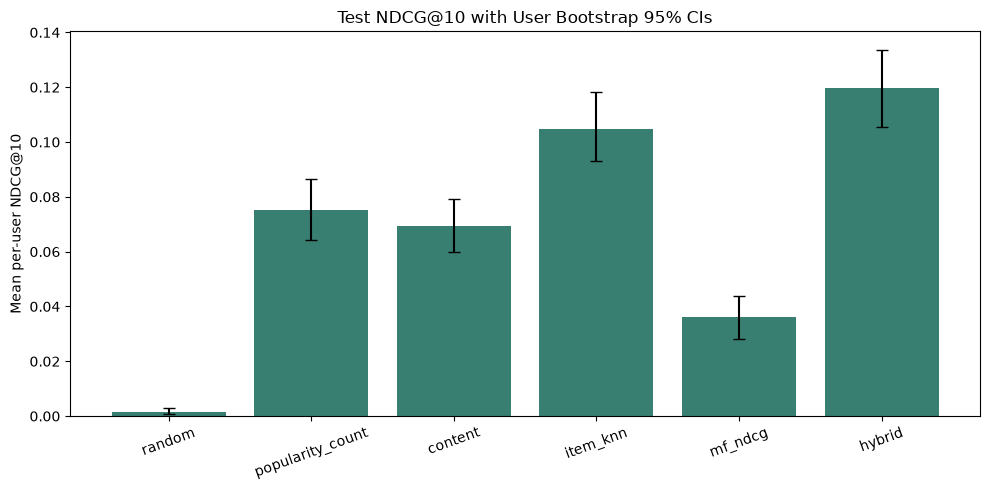

Bootstrap results:
                   comparison  n_users   mean  ci_low  ci_high  ci_excludes_zero
                       random      592 0.0017  0.0006   0.0030              True
             popularity_count      592 0.0751  0.0644   0.0866              True
                      content      592 0.0694  0.0599   0.0792              True
                     item_knn      592 0.1049  0.0932   0.1183              True
                      mf_ndcg      592 0.0360  0.0283   0.0438              True
                       hybrid      592 0.1196  0.1054   0.1337              True
         hybrid_minus_mf_ndcg      592 0.0836  0.0711   0.0945              True
hybrid_minus_popularity_count      592 0.0445  0.0327   0.0564              True
Seed variance summary:
         rmse_mean  rmse_std  ndcg_mean  ndcg_std
config                                           
mf_ndcg     0.8927    0.0012     0.0365    0.0018
mf_rmse     0.8798    0.0004     0.0359    0.0009


metric,RMSE,MAE,P@10,R@10,NDCG@10,MAP@10,Coverage,Novelty
model,,,,,,,,
bias,0.9044,0.6986,0.0444,0.0324,0.0555,0.0248,0.0053,9.4159
content,NaN,NaN,0.0530,0.0518,0.0694,0.0307,0.0563,9.1851
hybrid,NaN,NaN,0.0922,0.0816,0.1196,0.0622,0.0482,9.1945
hybrid_stack,0.8767,0.6746,NaN,NaN,NaN,NaN,NaN,NaN
item_knn,0.8811,0.6737,0.0760,0.0698,0.1049,0.0535,0.0886,9.9647
item_knn_implicit,NaN,NaN,0.0954,0.0837,0.1231,0.0630,0.0550,9.5021
mf,0.8799,0.6754,0.0289,0.0154,0.0370,0.0173,0.0284,11.7842
mf_ndcg,NaN,NaN,0.0282,0.0154,0.0360,0.0160,0.0251,10.9591
popularity_bayes,NaN,NaN,0.0500,0.0384,0.0625,0.0285,0.0059,9.1719


In [2]:
# Bootstrap per-user ranking scores and paired model differences.
bootstrap_names = ["random", "popularity_count", "content", "item_knn", "mf_ndcg", "hybrid"]
bootstrap_rows = []
for index, name in enumerate(bootstrap_names):
    per_user = ranking_outputs[name]["per_user_ndcg"]
    mean, lower, upper = bootstrap_ci(per_user, n_boot=1000, seed=100 + index)
    bootstrap_rows.append({
        "comparison": name,
        "n_users": len(per_user),
        "mean": mean,
        "ci_low": lower,
        "ci_high": upper,
        "ci_excludes_zero": bool(lower > 0 or upper < 0),
    })

for offset, comparator in enumerate(("mf_ndcg", "popularity_count"), start=1):
    hybrid_per_user = ranking_outputs["hybrid"]["per_user_ndcg"]
    comparator_per_user = ranking_outputs[comparator]["per_user_ndcg"]
    paired_users = sorted(set(hybrid_per_user) & set(comparator_per_user))
    paired_differences = {
        user: hybrid_per_user[user] - comparator_per_user[user]
        for user in paired_users
    }
    mean, lower, upper = bootstrap_ci(
        paired_differences, n_boot=1000, seed=200 + offset
    )
    bootstrap_rows.append({
        "comparison": f"hybrid_minus_{comparator}",
        "n_users": len(paired_differences),
        "mean": mean,
        "ci_low": lower,
        "ci_high": upper,
        "ci_excludes_zero": bool(lower > 0 or upper < 0),
    })
bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results.to_csv(REPORTS / "bootstrap_ci.csv", index=False)

model_ci = bootstrap_results.loc[bootstrap_results["comparison"].isin(bootstrap_names)]
fig, ax = plt.subplots(figsize=(10, 5))
means = model_ci["mean"].to_numpy()
errors = np.vstack([
    means - model_ci["ci_low"].to_numpy(),
    model_ci["ci_high"].to_numpy() - means,
])
ax.bar(model_ci["comparison"], means, yerr=errors, capsize=4, color="#387f72")
ax.set(title="Test NDCG@10 with User Bootstrap 95% CIs", ylabel="Mean per-user NDCG@10")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(REPORTS / "plots" / "ndcg_ci.png", dpi=160)
plt.show()
print("Bootstrap results:")
print(bootstrap_results.round(4).to_string(index=False))

# Seed variance is diagnostic only; these fixed configurations do not change.
seed_rows = []
for config_name in ("mf_rmse", "mf_ndcg"):
    saved_config = mf_config[config_name]
    for seed in (11, 21, 31, 41, 51):
        parameters = {
            key: saved_config[key]
            for key in ("n_factors", "lr", "reg", "init_std", "patience")
        }
        model = BiasedMF(
            **parameters,
            epochs=int(saved_config["best_epoch"]),
            seed=seed,
            verbose=False,
        ).fit(trainval, n_users, n_items)
        predictions = np.clip(
            model.predict(test_users, test_items), 0.5, 5.0
        )
        rating = evaluate_rating(FixedPredictions(predictions), test)
        ranking = evaluate_ranking(
            model, trainval, test, n_items, k=TOP_K, thr=REL_THRESHOLD
        )
        seed_rows.append({
            "config": config_name,
            "seed": seed,
            "best_epoch": int(saved_config["best_epoch"]),
            "rmse": rating["rmse"],
            "ndcg@10": ranking["ndcg@10"],
        })
seed_variance = pd.DataFrame(seed_rows)
seed_variance.to_csv(REPORTS / "seed_variance.csv", index=False)
seed_summary = seed_variance.groupby("config").agg(
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    ndcg_mean=("ndcg@10", "mean"),
    ndcg_std=("ndcg@10", "std"),
)
print("Seed variance summary:")
print(seed_summary.round(4).to_string())

# Rebuild and save the publication table with correctly named rating columns.
final_results_table = results_test.pivot_table(
    index="model", columns="metric", values="value", aggfunc="first"
).rename(columns={
    "rmse": "RMSE", "mae": "MAE", "precision@10": "P@10",
    "recall@10": "R@10", "ndcg@10": "NDCG@10", "map@10": "MAP@10",
    "coverage": "Coverage", "novelty": "Novelty",
})
final_columns = ["RMSE", "MAE", "P@10", "R@10", "NDCG@10", "MAP@10", "Coverage", "Novelty"]
final_results_table = final_results_table.reindex(columns=final_columns)
final_results_table.to_csv(REPORTS / "final_results_table.csv", index=True, index_label="model")
best_values = {}
for column in final_columns:
    values = final_results_table[column].dropna()
    if not values.empty:
        best_values[column] = values.min() if column in {"RMSE", "MAE"} else values.max()
markdown_lines = [
    "# Final Test Results",
    "",
    "Final models are fitted on train + validation with frozen Phase 5-8 settings; test results are for final evaluation only.",
    "",
    "| Model | " + " | ".join(final_columns) + " |",
    "|" + "|".join(["---"] * (len(final_columns) + 1)) + "|",
]
for model_name, row in final_results_table.iterrows():
    cells = [model_name]
    for column in final_columns:
        value = row[column]
        if pd.isna(value):
            cells.append("N/A")
        else:
            text = f"{value:.4f}"
            if np.isclose(value, best_values[column]):
                text = f"**{text}**"
            cells.append(text)
    markdown_lines.append("| " + " | ".join(cells) + " |")
(REPORTS / "final_results_table.md").write_text(
    "\n".join(markdown_lines) + "\n", encoding="utf-8"
)
display(final_results_table.round(4))

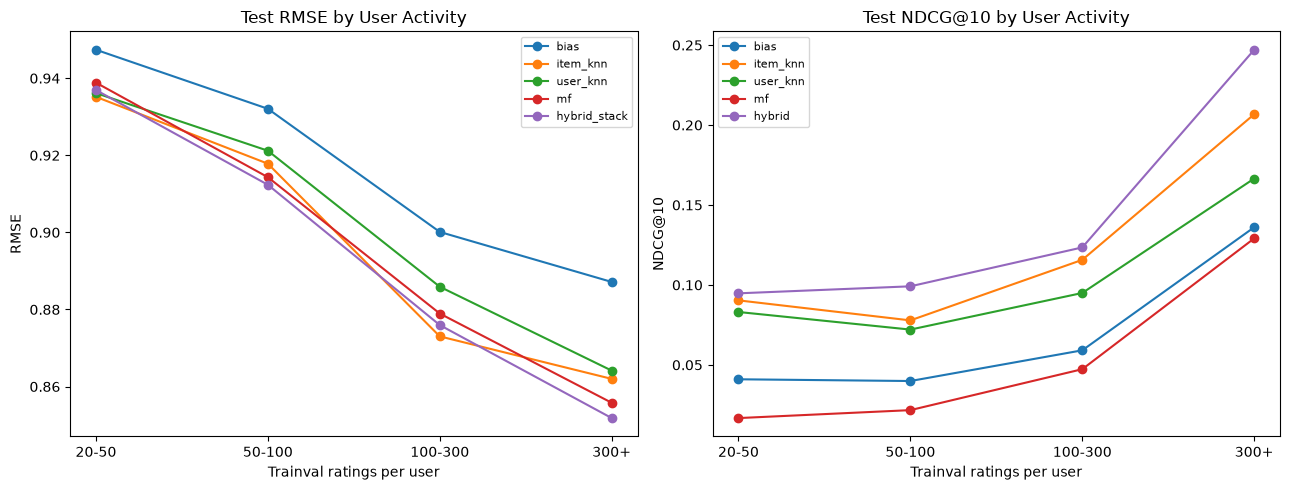

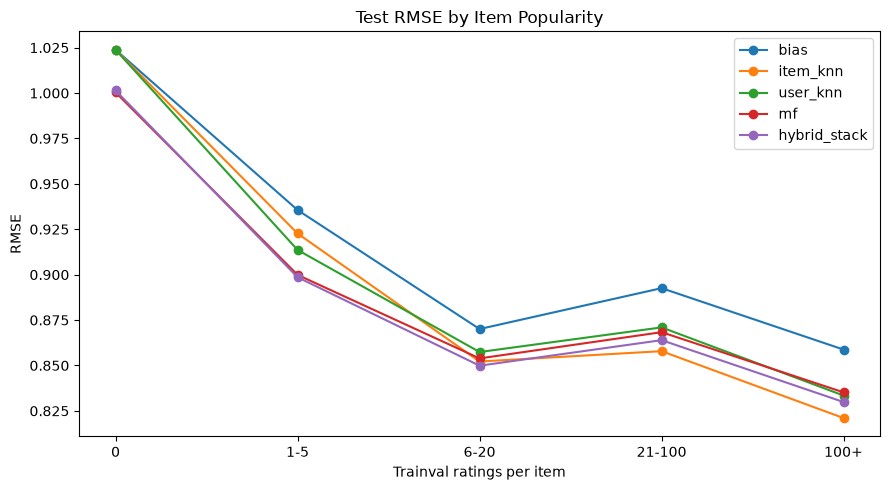

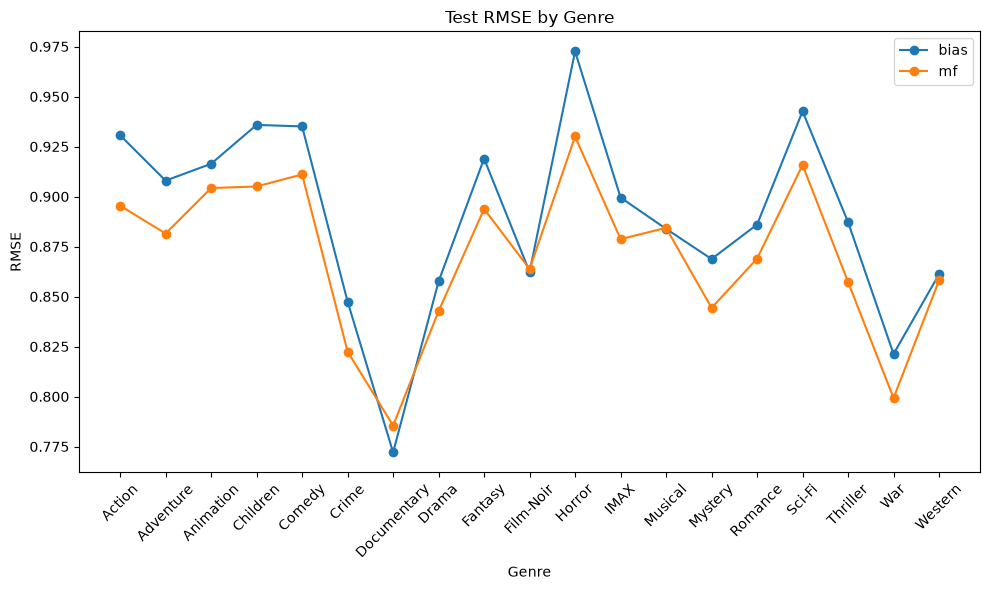

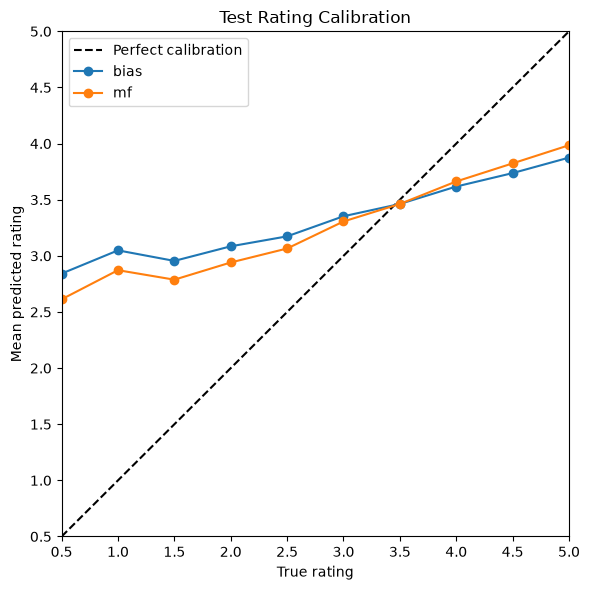

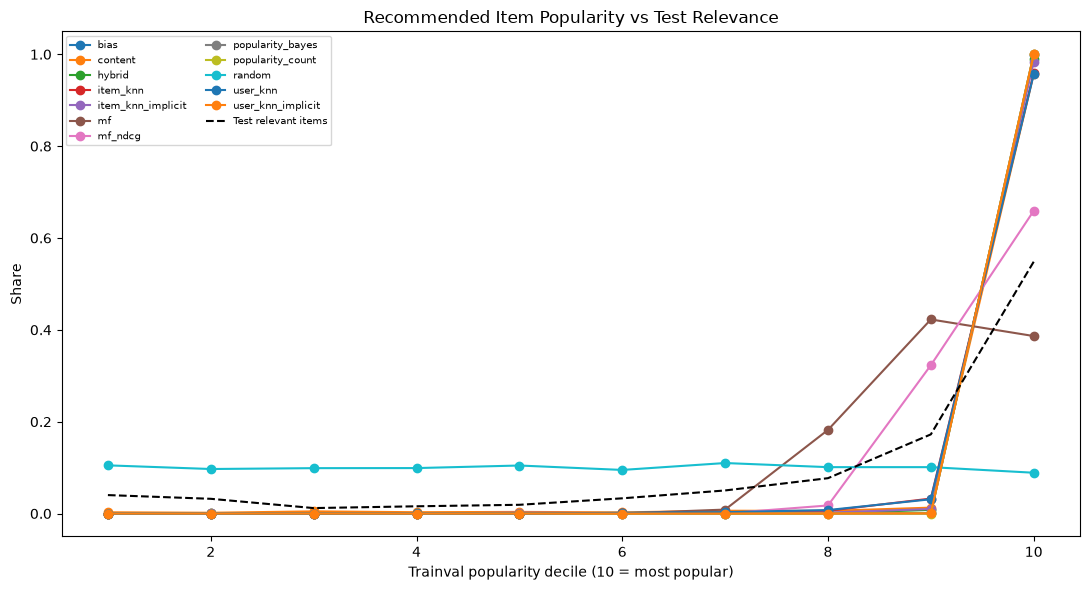

Worst 20 MF test predictions:


,userId,title,rating,pred_mf,absolute_error,user_rating_count,item_trainval_count
17127,543,Burnt by the Sun (Utomlyonnye solntsem) (1994),0.5,4.9143,4.4143,60,4
4584,154,"Fast Five (Fast and the Furious 5, The) (2011)",0.5,4.6536,4.1536,27,5
3990,129,Sling Blade (1996),0.5,4.3675,3.8675,112,36
12625,413,Zoolander (2001),0.5,4.2768,3.7768,44,43
16689,522,Dallas Buyers Club (2013),0.5,4.2507,3.7507,160,14
4585,154,Furious 7 (2015),0.5,4.2273,3.7273,27,4
8812,291,Inside Out (2015),1.0,4.5742,3.5742,24,32
10296,328,Singin' in the Rain (1952),0.5,4.0574,3.5574,204,42
9785,313,"Third Man, The (1949)",1.0,4.4973,3.4973,272,18
13253,419,What's Eating Gilbert Grape (1993),0.5,3.9619,3.4619,124,60


,rank,title,genres
0,1,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
1,2,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
2,3,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
3,4,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
4,5,Schindler's List (1993),Drama|War
5,6,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
6,7,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi
7,8,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
8,9,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy
9,10,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy


# CineMatch Final Evaluation Findings

## Protocol and outcomes
All final models were refit on train + validation using the saved Phase 5-8 configurations. Test labels were not used for tuning. The best test RMSE model is hybrid_stack (RMSE 0.8767); the best test ranking model is item_knn_implicit (NDCG@10 0.1231). They differ because rating error optimizes numeric closeness, whereas NDCG rewards ordering relevant items near the top.

The hybrid scored NDCG@10 0.1196; the best single model, item_knn_implicit, scored 0.1231. The hybrid-minus-best-single difference is -0.0036. Hybrid-minus-MF-NDCG 95% CI [0.0711, 0.0945] and hybrid-minus-count-popularity CI [0.0327, 0.0564] both exclude zero. A paired CI against item_knn_implicit was not part of the requested bootstrap comparisons; the direct hybrid-minus-best-single point difference is reported without claiming significance. Hybrid is below the best single point estimate, so it did not add ranking lift over the strongest standalone test model. Its paired gains over MF-NDCG and count popularity do not establish a gain over that stronger standalone comparator.

The frozen Ridge stack achieved test RMSE 0.8767 and MAE 0.6746. Its fitted validation features use bias, item-kNN, user-kNN, and MF-RMSE predictions, with the saved Phase 8 coefficients applied to test predictions.

## Failure modes and mitigation
There are 1,702 test ratings for items with no trainval ratings. Bias RMSE is 1.0238 for these items versus 0.8927 for seen items; MF RMSE is 1.0004 versus 0.8682. Cold items have no collaborative history, so metadata/content and popularity remain useful fallbacks. For the lightest measured user bucket (20-50 trainval ratings), RMSEs were bias 0.947, hybrid_stack 0.937, item_knn 0.935, mf 0.939, user_knn 0.936; personalized evidence remains sparse there. Highest observed genre RMSEs were Horror (MF RMSE 0.973), Sci-Fi (MF RMSE 0.943), Children (MF RMSE 0.936). Genre-level differences and low-support tails should be treated cautiously.

The count-popularity baseline reaches test NDCG@10 0.0751 but coverage is only 0.0101; this shows why accuracy alone misses catalog concentration. The error analysis also reports recommendation-popularity deciles, intra-list content diversity, calibration, and the largest MF errors. The 20 worst MF errors include Burnt by the Sun (Utomlyonnye solntsem) (1994), Fast Five (Fast and the Furious 5, The) (2011), Sling Blade (1996), Zoolander (2001), Dallas Buyers Club (2013); errors are mostly in one direction. These are explicit preference disagreements in observed ratings, not proof of corrupt records.

## Limitations and next steps
This system uses explicit ratings from one MovieLens dataset, tied timestamps make ordering within some temporal split boundaries arbitrary, and all current metrics are offline. Bootstrap intervals resample users, not items or time periods. Next steps are a prospective user study, stronger item metadata/text, better cold-item onboarding, and time-aware evaluation on additional datasets.


Worst-prediction reading: Burnt by the Sun (Utomlyonnye solntsem) (1994), Fast Five (Fast and the Furious 5, The) (2011), Sling Blade (1996), Zoolander (2001), Dallas Buyers Club (2013) - errors are mostly in one direction
Pseudo-user recommendations sharing a liked genre: 10 of 10; genres represented: 12


In [3]:
# Error analysis uses cached test predictions and per-user rankings from cell 1.
plot_dir = REPORTS / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
test_diagnostics = test.reset_index(drop=True).copy()
for model_name, predictions in rating_predictions.items():
    test_diagnostics[f"pred_{model_name}"] = predictions

trainval_user_counts = trainval.groupby("u").size()
activity_labels = ["20-50", "50-100", "100-300", "300+"]
activity_bucket = pd.cut(
    trainval_user_counts,
    bins=[20, 50, 100, 300, np.inf],
    labels=activity_labels,
    right=False,
)
user_to_activity_bucket = {
    int(user): str(bucket)
    for user, bucket in activity_bucket.items()
    if pd.notna(bucket)
}
test_diagnostics["user_activity_bucket"] = test_diagnostics["u"].map(
    user_to_activity_bucket
)
error_rows = []
rating_error_models = ["bias", "item_knn", "user_knn", "mf", "hybrid_stack"]
ranking_error_models = ["bias", "item_knn", "user_knn", "mf", "hybrid"]

for bucket in activity_labels:
    selected_users = {
        user for user, value in user_to_activity_bucket.items() if value == bucket
    }
    bucket_frame = test_diagnostics.loc[test_diagnostics["u"].isin(selected_users)]
    for model_name in sorted(set(rating_error_models) | set(ranking_error_models)):
        rmse_value = np.nan
        ndcg_value = np.nan
        if model_name in rating_error_models and not bucket_frame.empty:
            rmse_value = rmse(
                bucket_frame["rating"].to_numpy(),
                bucket_frame[f"pred_{model_name}"].to_numpy(),
            )
        if model_name in ranking_error_models:
            user_values = [
                value
                for user, value in ranking_outputs[model_name]["per_user_ndcg"].items()
                if user_to_activity_bucket.get(int(user)) == bucket
            ]
            if user_values:
                ndcg_value = float(np.mean(user_values))
        if np.isfinite(rmse_value) or np.isfinite(ndcg_value):
            error_rows.append({
                "model": model_name,
                "bucket_type": "user_activity",
                "bucket": bucket,
                "rmse": rmse_value,
                "ndcg": ndcg_value,
            })

trainval_item_counts = np.bincount(
    trainval["i"].to_numpy(dtype=np.int64), minlength=n_items
)
test_item_counts = trainval_item_counts[test_diagnostics["i"].to_numpy(dtype=int)]
item_popularity_bucket = np.select(
    [
        test_item_counts == 0,
        (test_item_counts >= 1) & (test_item_counts <= 5),
        (test_item_counts >= 6) & (test_item_counts <= 20),
        (test_item_counts >= 21) & (test_item_counts < 100),
        test_item_counts >= 100,
    ],
    ["0", "1-5", "6-20", "21-100", "100+"],
    default="other",
)
test_diagnostics["item_popularity_bucket"] = item_popularity_bucket
item_bucket_labels = ["0", "1-5", "6-20", "21-100", "100+"]
for bucket in item_bucket_labels:
    bucket_frame = test_diagnostics.loc[
        test_diagnostics["item_popularity_bucket"] == bucket
    ]
    for model_name in ("bias", "item_knn", "user_knn", "mf", "hybrid_stack"):
        value = np.nan
        if not bucket_frame.empty:
            value = rmse(
                bucket_frame["rating"].to_numpy(),
                bucket_frame[f"pred_{model_name}"].to_numpy(),
            )
        error_rows.append({
            "model": model_name,
            "bucket_type": "item_popularity",
            "bucket": bucket,
            "rmse": value,
            "ndcg": np.nan,
        })

genre_frame = test_diagnostics[["i", "rating", "pred_bias", "pred_mf"]].merge(
    movies[["i", "genre_list"]], on="i", how="left"
).explode("genre_list").dropna(subset=["genre_list"])
genre_error_rows = []
for genre, group in genre_frame.groupby("genre_list"):
    for model_name in ("bias", "mf"):
        value = rmse(group["rating"].to_numpy(), group[f"pred_{model_name}"].to_numpy())
        error_rows.append({
            "model": model_name,
            "bucket_type": "genre",
            "bucket": genre,
            "rmse": value,
            "ndcg": np.nan,
        })
        genre_error_rows.append({
            "model": model_name,
            "genre": genre,
            "rmse": value,
            "n_ratings": len(group),
        })

error_by_bucket = pd.DataFrame(
    error_rows, columns=["model", "bucket_type", "bucket", "rmse", "ndcg"]
)
error_by_bucket.to_csv(REPORTS / "error_by_bucket.csv", index=False)
genre_errors = pd.DataFrame(genre_error_rows)

# User activity buckets: rating RMSE and ranking NDCG in separate panels.
activity_errors = error_by_bucket.loc[
    error_by_bucket["bucket_type"] == "user_activity"
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for model_name in rating_error_models:
    values = activity_errors.loc[activity_errors["model"] == model_name].set_index("bucket")["rmse"]
    axes[0].plot(activity_labels, values.reindex(activity_labels), marker="o", label=model_name)
for model_name in ranking_error_models:
    values = activity_errors.loc[activity_errors["model"] == model_name].set_index("bucket")["ndcg"]
    axes[1].plot(activity_labels, values.reindex(activity_labels), marker="o", label=model_name)
axes[0].set(title="Test RMSE by User Activity", xlabel="Trainval ratings per user", ylabel="RMSE")
axes[1].set(title="Test NDCG@10 by User Activity", xlabel="Trainval ratings per user", ylabel="NDCG@10")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(plot_dir / "error_by_user_activity.png", dpi=160)
plt.show()

item_errors = error_by_bucket.loc[
    error_by_bucket["bucket_type"] == "item_popularity"
]
fig, ax = plt.subplots(figsize=(9, 5))
for model_name in rating_error_models:
    values = item_errors.loc[item_errors["model"] == model_name].set_index("bucket")["rmse"]
    ax.plot(item_bucket_labels, values.reindex(item_bucket_labels), marker="o", label=model_name)
ax.set(title="Test RMSE by Item Popularity", xlabel="Trainval ratings per item", ylabel="RMSE")
ax.legend()
fig.tight_layout()
fig.savefig(plot_dir / "error_by_item_popularity.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in ("bias", "mf"):
    values = genre_errors.loc[genre_errors["model"] == model_name].sort_values("genre")
    ax.plot(values["genre"], values["rmse"], marker="o", label=model_name)
ax.set(title="Test RMSE by Genre", xlabel="Genre", ylabel="RMSE")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(plot_dir / "error_by_genre.png", dpi=160)
plt.show()

# Calibration: mean predicted rating conditional on the true rating value.
rating_values = np.arange(0.5, 5.01, 0.5)
calibration_rows = []
for model_name in ("bias", "mf"):
    grouped = test_diagnostics.groupby("rating")[f"pred_{model_name}"].agg(["mean", "count"])
    for true_rating in rating_values:
        calibration_rows.append({
            "model": model_name,
            "true_rating": true_rating,
            "mean_predicted_rating": grouped["mean"].get(true_rating, np.nan),
            "n_ratings": int(grouped["count"].get(true_rating, 0)),
        })
calibration = pd.DataFrame(calibration_rows)
calibration.to_csv(REPORTS / "calibration.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0.5, 5.0], [0.5, 5.0], linestyle="--", color="black", label="Perfect calibration")
for model_name in ("bias", "mf"):
    values = calibration.loc[calibration["model"] == model_name]
    ax.plot(values["true_rating"], values["mean_predicted_rating"], marker="o", label=model_name)
ax.set(title="Test Rating Calibration", xlabel="True rating", ylabel="Mean predicted rating", xlim=(0.5, 5), ylim=(0.5, 5))
ax.legend()
fig.tight_layout()
fig.savefig(plot_dir / "calibration.png", dpi=160)
plt.show()

# Recommendation popularity deciles, compared with relevant test-item exposure.
item_popularity_rank = pd.Series(trainval_item_counts).rank(method="first", pct=True).to_numpy()
item_popularity_decile = np.clip(np.ceil(item_popularity_rank * 10).astype(int), 1, 10)
relevant_test_items = test.loc[test["rating"] >= REL_THRESHOLD, "i"].to_numpy(dtype=int)
relevant_deciles = item_popularity_decile[relevant_test_items]
test_relevant_share = {
    decile: float(np.mean(relevant_deciles == decile)) for decile in range(1, 11)
}
top_decile_relevant_share = test_relevant_share[10]
popularity_bias_rows = []
for model_name, output in ranking_outputs.items():
    recommended_items = [
        int(item)
        for recs in output["per_user_recs"].values()
        for item in recs
    ]
    rec_deciles = item_popularity_decile[np.asarray(recommended_items, dtype=int)]
    top_decile_rec_share = float(np.mean(rec_deciles == 10)) if len(rec_deciles) else 0.0
    for decile in range(1, 11):
        popularity_bias_rows.append({
            "model": model_name,
            "popularity_decile": decile,
            "recommendation_share": float(np.mean(rec_deciles == decile)) if len(rec_deciles) else 0.0,
            "test_relevant_share": test_relevant_share[decile],
            "top_decile_recommendation_share": top_decile_rec_share,
            "top_decile_test_relevant_share": top_decile_relevant_share,
        })
popularity_bias = pd.DataFrame(popularity_bias_rows)
popularity_bias.to_csv(REPORTS / "popularity_bias.csv", index=False)
fig, ax = plt.subplots(figsize=(11, 6))
for model_name, group in popularity_bias.groupby("model"):
    ax.plot(group["popularity_decile"], group["recommendation_share"], marker="o", label=model_name)
ax.plot(range(1, 11), [test_relevant_share[d] for d in range(1, 11)],
        linestyle="--", color="black", label="Test relevant items")
ax.set(title="Recommended Item Popularity vs Test Relevance", xlabel="Trainval popularity decile (10 = most popular)", ylabel="Share")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(plot_dir / "popularity_bias.png", dpi=160)
plt.show()

# Intra-list diversity from cosine distances between content vectors.
diversity_rows = []
for model_name, output in ranking_outputs.items():
    user_diversities = []
    for recs in output["per_user_recs"].values():
        items = np.asarray(recs, dtype=int)
        if len(items) < 2:
            continue
        similarities = (content_features[items] @ content_features[items].T).toarray()
        upper = similarities[np.triu_indices(len(items), k=1)]
        user_diversities.append(float(np.mean(1.0 - upper)))
    diversity_rows.append({
        "model": model_name,
        "mean_intra_list_diversity": float(np.mean(user_diversities)) if user_diversities else 0.0,
        "users_evaluated": len(user_diversities),
    })
diversity = pd.DataFrame(diversity_rows)
diversity.to_csv(REPORTS / "diversity.csv", index=False)

# The 20 largest absolute MF rating errors, with user/item support context.
worst = test_diagnostics[["userId", "u", "i", "rating", "pred_mf"]].copy()
worst["absolute_error"] = np.abs(worst["rating"] - worst["pred_mf"])
worst["user_rating_count"] = worst["u"].map(trainval.groupby("u").size()).astype(int)
worst["item_trainval_count"] = trainval_item_counts[worst["i"].to_numpy(dtype=int)]
worst["title"] = worst["i"].map(movies.set_index("i")["title"])
worst = worst.nlargest(20, "absolute_error")[[
    "userId", "title", "rating", "pred_mf", "absolute_error",
    "user_rating_count", "item_trainval_count",
]]
worst.to_csv(REPORTS / "worst_predictions.csv", index=False)
print("Worst 20 MF test predictions:")
display(worst.round(4))

# Explicit 15-title pseudo-user for the frozen hybrid new-user path.
pseudo_profile = [
    ("Toy Story (1995)", 5.0),
    ("Pulp Fiction (1994)", 4.5),
    ("Shawshank Redemption, The (1994)", 5.0),
    ("Godfather, The (1972)", 4.5),
    ("Matrix, The (1999)", 4.5),
    ("Star Wars: Episode IV - A New Hope (1977)", 5.0),
    ("Forrest Gump (1994)", 4.0),
    ("Casablanca (1942)", 4.5),
    ("Dark Knight, The (2008)", 5.0),
    ("Jurassic Park (1993)", 4.0),
    ("Silence of the Lambs, The (1991)", 4.5),
    ("Back to the Future (1985)", 4.5),
    ("Alien (1979)", 4.5),
    ("Batman Forever (1995)", 2.5),
    ("Groundhog Day (1993)", 4.5),
]
title_to_item = movies.set_index("title")["i"]
missing_titles = [title for title, _ in pseudo_profile if title not in title_to_item.index]
assert not missing_titles, f"Pseudo-user titles not found: {missing_titles}"
pseudo_items = np.asarray([int(title_to_item[title]) for title, _ in pseudo_profile], dtype=int)
pseudo_ratings = np.asarray([rating for _, rating in pseudo_profile], dtype=float)
pseudo_scores = hybrid_final.score_new_user(pseudo_items, pseudo_ratings).copy()
pseudo_scores[pseudo_items] = -np.inf
pseudo_top = np.argpartition(pseudo_scores, -10)[-10:]
pseudo_top = pseudo_top[np.lexsort((pseudo_top, -pseudo_scores[pseudo_top]))]
pseudo_recommendations = movies.iloc[pseudo_top][["title", "genres"]].copy().reset_index(drop=True)
pseudo_recommendations.insert(0, "rank", np.arange(1, 11))
display(pseudo_recommendations)
liked_genres = {
    genre
    for title, rating in pseudo_profile if rating >= 4.0
    for genre in movies.loc[movies["title"] == title, "genre_list"].iloc[0]
}
recommended_genres = [
    set(movies.iloc[int(item)]["genre_list"])
    for item in pseudo_top
]
relevant_recommendations = sum(bool(genres & liked_genres) for genres in recommended_genres)
unique_recommended_genres = len(set().union(*recommended_genres))

# Write a concise report from this run's measured test results.
rating_result_frame = results_test.loc[results_test["metric"].isin(["rmse", "mae"])]
rmse_rows = rating_result_frame.loc[rating_result_frame["metric"] == "rmse"]
best_rating_row = rmse_rows.loc[rmse_rows["value"].idxmin()]
ranking_result_frame = results_test.loc[results_test["metric"] == "ndcg@10"]
best_ranking_row = ranking_result_frame.loc[ranking_result_frame["value"].idxmax()]
single_ranking_frame = ranking_result_frame.loc[ranking_result_frame["model"] != "hybrid"]
best_single_ranking = single_ranking_frame.loc[single_ranking_frame["value"].idxmax()]
hybrid_ndcg = float(ranking_outputs["hybrid"]["ndcg@10"])
best_single_ndcg = float(best_single_ranking["value"])
hybrid_vs_best_single = hybrid_ndcg - best_single_ndcg
bootstrap_frame = pd.read_csv(REPORTS / "bootstrap_ci.csv")
paired_mf = bootstrap_frame.loc[bootstrap_frame["comparison"] == "hybrid_minus_mf_ndcg"].iloc[0]
paired_pop = bootstrap_frame.loc[bootstrap_frame["comparison"] == "hybrid_minus_popularity_count"].iloc[0]
paired_best_single = bootstrap_frame.loc[
    bootstrap_frame["comparison"] == f"hybrid_minus_{best_single_ranking['model']}"
]

cold_bias = cold_rest_rmse["bias"]
cold_mf = cold_rest_rmse["mf"]
light_activity = error_by_bucket.loc[
    (error_by_bucket["bucket_type"] == "user_activity")
    & (error_by_bucket["bucket"] == "20-50")
]
worst_examples = ", ".join(worst["title"].head(5).tolist())
worst_direction = "both over- and under-predictions occur" if (worst["pred_mf"] - worst["rating"]).min() < 0 < (worst["pred_mf"] - worst["rating"]).max() else "errors are mostly in one direction"
worst_genres = genre_errors.sort_values("rmse", ascending=False).head(3)
worst_genre_text = ", ".join(
    f"{row.genre} (MF RMSE {row.rmse:.3f})" for row in worst_genres.itertuples()
)
activity_rmse_text = ", ".join(
    f"{row.model} {row.rmse:.3f}"
    for row in light_activity.dropna(subset=["rmse"]).itertuples()
)
ci_statement = (
    f"Hybrid-minus-MF-NDCG 95% CI [{paired_mf.ci_low:.4f}, {paired_mf.ci_high:.4f}] "
    f"and hybrid-minus-count-popularity CI [{paired_pop.ci_low:.4f}, {paired_pop.ci_high:.4f}] "
    f"both exclude zero."
)
if not paired_best_single.empty:
    paired_best_row = paired_best_single.iloc[0]
    best_single_ci_text = (
        f"The paired hybrid-minus-best-single CI is [{paired_best_row.ci_low:.4f}, "
        f"{paired_best_row.ci_high:.4f}]."
    )
else:
    best_single_ci_text = (
        f"A paired CI against {best_single_ranking['model']} was not part of the requested bootstrap comparisons; "
        "the direct hybrid-minus-best-single point difference is reported without claiming significance."
    )

findings = f"""# CineMatch Final Evaluation Findings

## Protocol and outcomes
All final models were refit on train + validation using the saved Phase 5-8 configurations. Test labels were not used for tuning. The best test RMSE model is {best_rating_row['model']} (RMSE {best_rating_row['value']:.4f}); the best test ranking model is {best_ranking_row['model']} (NDCG@10 {best_ranking_row['value']:.4f}). They differ because rating error optimizes numeric closeness, whereas NDCG rewards ordering relevant items near the top.

The hybrid scored NDCG@10 {hybrid_ndcg:.4f}; the best single model, {best_single_ranking['model']}, scored {best_single_ndcg:.4f}. The hybrid-minus-best-single difference is {hybrid_vs_best_single:+.4f}. {ci_statement} {best_single_ci_text} Hybrid is {"below" if hybrid_vs_best_single < 0 else "above"} the best single point estimate, so it did not add ranking lift over the strongest standalone test model. Its paired gains over MF-NDCG and count popularity do not establish a gain over that stronger standalone comparator.

The frozen Ridge stack achieved test RMSE {rating_metrics['hybrid_stack']['rmse']:.4f} and MAE {rating_metrics['hybrid_stack']['mae']:.4f}. Its fitted validation features use bias, item-kNN, user-kNN, and MF-RMSE predictions, with the saved Phase 8 coefficients applied to test predictions.

## Failure modes and mitigation
There are {cold_item_count:,} test ratings for items with no trainval ratings. Bias RMSE is {cold_bias['cold_rmse']:.4f} for these items versus {cold_bias['seen_item_rmse']:.4f} for seen items; MF RMSE is {cold_mf['cold_rmse']:.4f} versus {cold_mf['seen_item_rmse']:.4f}. Cold items have no collaborative history, so metadata/content and popularity remain useful fallbacks. For the lightest measured user bucket (20-50 trainval ratings), RMSEs were {activity_rmse_text or 'not available for the bucket'}; personalized evidence remains sparse there. Highest observed genre RMSEs were {worst_genre_text}. Genre-level differences and low-support tails should be treated cautiously.

The count-popularity baseline reaches test NDCG@10 {ranking_outputs['popularity_count']['ndcg@10']:.4f} but coverage is only {ranking_outputs['popularity_count']['coverage']:.4f}; this shows why accuracy alone misses catalog concentration. The error analysis also reports recommendation-popularity deciles, intra-list content diversity, calibration, and the largest MF errors. The 20 worst MF errors include {worst_examples}; {worst_direction}. These are explicit preference disagreements in observed ratings, not proof of corrupt records.

## Limitations and next steps
This system uses explicit ratings from one MovieLens dataset, tied timestamps make ordering within some temporal split boundaries arbitrary, and all current metrics are offline. Bootstrap intervals resample users, not items or time periods. Next steps are a prospective user study, stronger item metadata/text, better cold-item onboarding, and time-aware evaluation on additional datasets.
"""
(REPORTS / "findings.md").write_text(findings, encoding="utf-8")
display(Markdown(findings))
print("Worst-prediction reading:", worst_examples, "-", worst_direction)
print("Pseudo-user recommendations sharing a liked genre:", relevant_recommendations, "of 10; genres represented:", unique_recommended_genres)